In [1]:
here::i_am("atac/archR/footprinting/footprinting.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(ArchR))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(edgeR))


BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 21

addArchRThreads(24)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/10_Eomes_invitro_gut/code


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
        

In [2]:
args = list()

# Metadata
args$metadata = file.path(io$basedir, '/results/atac/archR/qc/sample_metadata_after_qc.txt.gz')

# Archr
args$archr_directory = file.path(io$basedir, 'processed/atac/archR')

# outdir
args$outdir = file.path(io$basedir, 'results/rna_atac/differential/Accessibility/')
dir.create(args$outdir, recursive=TRUE, showWarnings =FALSE)

In [3]:
seurat = readRDS(file.path(io$basedir, 'results/rna/differential/seurat_full.rds'))

In [4]:
meta_seurat = as.data.table(seurat@meta.data, keep.rownames=T) %>% setnames('rn', 'cell')

In [22]:
# Load meta
meta = fread(args$metadata)[day!='D2.5'][pass_atacQC==TRUE][!is.na(celltype)] # remove D2.5 cells

In [23]:
meta2 = merge(meta, meta_seurat[,c('cell', 'celltypes_v1')], by='cell')

In [24]:
meta2 = meta2[celltypes_v1 %in% c('PS_T+','APS_Mixl1-','Epiblast_Dnmt3b+','PS_Epcam+', 'APS_Mixl1+')]

In [25]:
meta2$celltypes_v1 = gsub('\\+', '1', gsub("\\-", "2", meta2$celltypes_v1))

In [26]:
unique(meta2$celltypes_v1)

[1] "PS_T1"            "APS_Mixl12"       "Epiblast_Dnmt3b1" "PS_Epcam1"       
[5] "APS_Mixl11"

In [27]:
ArchRProject <- loadArchRProject(args$archr_directory)[meta2$cell]

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [28]:
meta2$celltypeV1_genotype = paste0(meta2$celltypes_v1, '_', meta2$genotype)

In [29]:
ArchRProject <- addCellColData(ArchRProj = ArchRProject, 
                                    data = as.character(meta2$celltypeV1_genotype),
                                    cells = meta2$cell,
                                    name = "celltypeV1_genotype",
                                    force=TRUE)

In [31]:
library(BSgenome.Mmusculus.UCSC.mm10)

Loading required package: BSgenome

Loading required package: rtracklayer



In [32]:
# Add group coverages
ArchRProject <- addGroupCoverages(ArchRProject, 
  groupBy = "celltypeV1_genotype",
  useLabels = TRUE,  # Need to use sample information, otherwise only 50 cells get used per condition. (bug in ArchR)
  minCells = 50,
  maxCells = 5000,
  force = TRUE
)

ArchR logging to : ArchRLogs/ArchR-addGroupCoverages-110849475cba73-Date-2023-05-30_Time-00-53-43.log
If there is an issue, please report to github with logFile!

APS_Mixl11_Eomes_KO (1 of 10) : CellGroups N = 2

APS_Mixl11_WT (2 of 10) : CellGroups N = 2

APS_Mixl12_Eomes_KO (3 of 10) : CellGroups N = 2

APS_Mixl12_WT (4 of 10) : CellGroups N = 2

Epiblast_Dnmt3b1_Eomes_KO (5 of 10) : CellGroups N = 2

Epiblast_Dnmt3b1_WT (6 of 10) : CellGroups N = 2

PS_Epcam1_Eomes_KO (7 of 10) : CellGroups N = 2

PS_Epcam1_WT (8 of 10) : CellGroups N = 2

PS_T1_Eomes_KO (9 of 10) : CellGroups N = 2

PS_T1_WT (10 of 10) : CellGroups N = 2

2023-05-30 00:53:46 : Further Sampled 10 Groups above the Max Fragments!, 0.04 mins elapsed.

2023-05-30 00:53:46 : Creating Coverage Files!, 0.046 mins elapsed.

2023-05-30 00:53:46 : Batch Execution w/ safelapply!, 0.046 mins elapsed.

2023-05-30 00:54:32 : Adding Kmer Bias to Coverage Files!, 0.821 mins elapsed.

Completed Kmer Bias Calculation

Adding Kmer Bia

In [43]:
saveRDS(ArchRProject@projectMetadata$GroupCoverages$celltypeV1_genotype, '/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR/GroupCoverages/celltype_genotype/GroupCoverages_metadata.rds')

In [177]:
# keep only relevant celltypes
keep = unique(opts$clusters2celltypes)[unique(opts$clusters2celltypes) != 'Blood_Progenitor']

In [178]:
# get motif positions
motifPositions <- getPositions(ArchRProject)

In [179]:
# motifs of interest
motifs <- c("Eomes", "Lhx1", "Etv2", "Cdx4", "Klf6", "Gata2", "Gata1", "Zic3", "Sox15", "Tbx20", "Tbx4")
#motifs = "Smad1"
markerMotifs <- unlist(lapply(motifs, function(x) grep(x, names(motifPositions), value = TRUE)))
markerMotifs

[1] "Eomes_768" "Lhx1_422"  "Etv2_270"  "Cdx4_481"  "Klf6_794"  "Gata2_383"
 [7] "Gata1_387" "Zic3_229"  "Sox15_737" "Tbx20_767" "Tbx4_761"

In [181]:
# get footprints
seFoot <- getFootprints(
  ArchRProj = ArchRProject, 
  positions = motifPositions[markerMotifs], 
  groupBy = "celltype_genotype"
)

ArchR logging to : ArchRLogs/ArchR-getFootprints-20a03e35d4ab8d-Date-2023-05-28_Time-12-33-55.log
If there is an issue, please report to github with logFile!

2023-05-28 12:33:55 : Computing Kmer Bias Table, 0.003 mins elapsed.

2023-05-28 12:34:10 : Finished Computing Kmer Tables, 0.258 mins elapsed.

2023-05-28 12:34:10 : Computing Footprints, 0.262 mins elapsed.

2023-05-28 12:34:25 : Computing Footprints Bias, 0.5 mins elapsed.

2023-05-28 12:34:32 : Summarizing Footprints, 0.624 mins elapsed.



In [182]:
seFoot

class: SummarizedExperiment 
dim: 1002 64 
metadata(1): Params
assays(11): Eomes_768 Lhx1_422 ... Tbx20_767 Tbx4_761
rownames: NULL
rowData names(2): x type
colnames(64): Allantois_Precursor-KO._.rv_eo_deg_day4_5_dtag
  Allantois_Precursor-KO._.rv_eo_deg_day4_dtag ...
  Primitive_Streak-WT._.rv_eo_deg_day3_5_control
  Primitive_Streak-WT._.2_Eo_DEG_G9_day4_VC
colData names(5): Group Name File nCells nInsertions

In [183]:
mclapply(keep, function(x){
    plotFootprints(
      seFoot = seFoot[, c(grep(paste0(x, '-KO'), colnames(seFoot)),
                         grep(paste0(x, '-WT'), colnames(seFoot)))],
      ArchRProj = ArchRProject, 
      normMethod = "Subtract",
      plotName = paste0('Footprints_', x),
      addDOC = FALSE,
      smoothWindow = 15
)
}, mc.cores=24)

[[1]]
[1] 0

[[2]]
[1] 0

[[3]]
[1] 0

[[4]]
[1] 0

[[5]]
[1] 0

[[6]]
[1] 0

[[7]]
[1] 0

[[8]]
[1] 0

[[9]]
[1] 0

[[10]]
[1] 0

# Silico ChIP

In [184]:
getwd()

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code/atac/archR/footprinting"

In [185]:
silicoChIP = readRDS('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/rna_atac/virtual_chipseq/pseudobulk/JASPAR/motifmatchr_virtual_chip.rds')

In [186]:
motifs

[1] "Eomes" "Lhx1"  "Etv2"  "Cdx4"  "Klf6"  "Gata2" "Gata1" "Zic3"  "Sox15"
[10] "Tbx20" "Tbx4"

In [187]:
markerMotifs

[1] "Eomes_768" "Lhx1_422"  "Etv2_270"  "Cdx4_481"  "Klf6_794"  "Gata2_383"
 [7] "Gata1_387" "Zic3_229"  "Sox15_737" "Tbx20_767" "Tbx4_761"

In [188]:
silico = lapply(1:length(motifs), function(i){
    print(motifs[i])
    keep_peaks = as.data.table(as.matrix((assay(silicoChIP[, toupper(motifs[i])], 'VirtualChipScores'))), keep.rownames=T) %>% 
        setnames(c('peak', 'score')) %>%
        .[score>0.15] %>%
        .[, chr:=str_split(peak, ':') %>% map_chr(1)] %>%
        .[, start:=str_split(str_split(peak, ':') %>% map_chr(2), '-') %>% map_chr(1)] %>%
        .[, end:=str_split(str_split(peak, ':') %>% map_chr(2), '-') %>% map_chr(2)] 
    overlap = findOverlaps(makeGRangesFromDataFrame(keep_peaks), motifPositions[[markerMotifs[i]]])
    silico = motifPositions[[markerMotifs[i]]][subjectHits(overlap)]
    return(silico)
})
names(silico) = markerMotifs

[1] "Eomes"
[1] "Lhx1"
[1] "Etv2"
[1] "Cdx4"
[1] "Klf6"
[1] "Gata2"
[1] "Gata1"
[1] "Zic3"
[1] "Sox15"
[1] "Tbx20"
[1] "Tbx4"


In [189]:
seFoot_silico <- getFootprints(
  ArchRProj = ArchRProject, 
  positions = silico[markerMotifs], 
  groupBy = "celltype_genotype"
)

ArchR logging to : ArchRLogs/ArchR-getFootprints-20a03e74c4447d-Date-2023-05-28_Time-12-34-44.log
If there is an issue, please report to github with logFile!

2023-05-28 12:34:44 : Computing Kmer Bias Table, 0.003 mins elapsed.

2023-05-28 12:34:50 : Finished Computing Kmer Tables, 0.094 mins elapsed.

2023-05-28 12:34:50 : Computing Footprints, 0.097 mins elapsed.

2023-05-28 12:35:01 : Computing Footprints Bias, 0.294 mins elapsed.

2023-05-28 12:35:08 : Summarizing Footprints, 0.408 mins elapsed.



In [190]:
mclapply(keep, function(x){
    plotFootprints(
      seFoot = seFoot_silico[, c(grep(paste0(x, '-KO'), colnames(seFoot_silico)),
                         grep(paste0(x, '-WT'), colnames(seFoot_silico)))],
      ArchRProj = ArchRProject, 
      normMethod = "Subtract",
      plotName = paste0('Footprints_silico_', x),
      addDOC = FALSE,
      smoothWindow = 15
)
}, mc.cores=24)

[[1]]
[1] 0

[[2]]
[1] 0

[[3]]
[1] 0

[[4]]
[1] 0

[[5]]
[1] 0

[[6]]
[1] 0

[[7]]
[1] 0

[[8]]
[1] 0

[[9]]
[1] 0

[[10]]
[1] 0

### Abs score filter

In [191]:
silico = mclapply(1:length(motifs), function(i){
    keep_peaks = as.data.table(as.matrix((assay(silicoChIP[, toupper(motifs[i])], 'VirtualChipScores'))), keep.rownames=T) %>% 
        setnames(c('peak', 'score')) %>%
        .[abs(score)>0.15] %>%
        .[, chr:=str_split(peak, ':') %>% map_chr(1)] %>%
        .[, start:=str_split(str_split(peak, ':') %>% map_chr(2), '-') %>% map_chr(1)] %>%
        .[, end:=str_split(str_split(peak, ':') %>% map_chr(2), '-') %>% map_chr(2)] 
    overlap = findOverlaps(makeGRangesFromDataFrame(keep_peaks), motifPositions[[markerMotifs[i]]])
    silico = motifPositions[[markerMotifs[i]]][subjectHits(overlap)]
    return(silico)
})
names(silico) = markerMotifs

In [192]:
seFoot_silico <- getFootprints(
  ArchRProj = ArchRProject, 
  positions = silico[markerMotifs], 
  groupBy = "celltype_genotype"
)

ArchR logging to : ArchRLogs/ArchR-getFootprints-20a03e729481e8-Date-2023-05-28_Time-12-35-17.log
If there is an issue, please report to github with logFile!

2023-05-28 12:35:17 : Computing Kmer Bias Table, 0.003 mins elapsed.

2023-05-28 12:35:23 : Finished Computing Kmer Tables, 0.101 mins elapsed.

2023-05-28 12:35:23 : Computing Footprints, 0.104 mins elapsed.

2023-05-28 12:35:35 : Computing Footprints Bias, 0.3 mins elapsed.

2023-05-28 12:35:41 : Summarizing Footprints, 0.403 mins elapsed.



In [193]:
mclapply(keep, function(x){
    plotFootprints(
      seFoot = seFoot_silico[, c(grep(paste0(x, '-KO'), colnames(seFoot_silico)),
                         grep(paste0(x, '-WT'), colnames(seFoot_silico)))],
      ArchRProj = ArchRProject, 
      normMethod = "Subtract",
      plotName = paste0('Footprints_silico_abs_', x),
      addDOC = FALSE,
      smoothWindow = 15
)
}, mc.cores=24)

[[1]]
[1] 0

[[2]]
[1] 0

[[3]]
[1] 0

[[4]]
[1] 0

[[5]]
[1] 0

[[6]]
[1] 0

[[7]]
[1] 0

[[8]]
[1] 0

[[9]]
[1] 0

[[10]]
[1] 0

### Abs score low filter

In [194]:
silico = mclapply(1:length(motifs), function(i){
    keep_peaks = as.data.table(as.matrix((assay(silicoChIP[, toupper(motifs[i])], 'VirtualChipScores'))), keep.rownames=T) %>% 
        setnames(c('peak', 'score')) %>%
        .[abs(score)>0.05] %>%
        .[, chr:=str_split(peak, ':') %>% map_chr(1)] %>%
        .[, start:=str_split(str_split(peak, ':') %>% map_chr(2), '-') %>% map_chr(1)] %>%
        .[, end:=str_split(str_split(peak, ':') %>% map_chr(2), '-') %>% map_chr(2)] 
    overlap = findOverlaps(makeGRangesFromDataFrame(keep_peaks), motifPositions[[markerMotifs[i]]])
    silico = motifPositions[[markerMotifs[i]]][subjectHits(overlap)]
    return(silico)
})
names(silico) = markerMotifs

In [195]:
seFoot_silico <- getFootprints(
  ArchRProj = ArchRProject, 
  positions = silico[markerMotifs], 
  groupBy = "celltype_genotype"
)

ArchR logging to : ArchRLogs/ArchR-getFootprints-20a03eb376b99-Date-2023-05-28_Time-12-35-50.log
If there is an issue, please report to github with logFile!

2023-05-28 12:35:50 : Computing Kmer Bias Table, 0.003 mins elapsed.

2023-05-28 12:35:58 : Finished Computing Kmer Tables, 0.128 mins elapsed.

2023-05-28 12:35:58 : Computing Footprints, 0.131 mins elapsed.

2023-05-28 12:36:10 : Computing Footprints Bias, 0.333 mins elapsed.

2023-05-28 12:36:17 : Summarizing Footprints, 0.457 mins elapsed.



In [196]:
mclapply(keep, function(x){
    plotFootprints(
      seFoot = seFoot_silico[, c(grep(paste0(x, '-KO'), colnames(seFoot_silico)),
                         grep(paste0(x, '-WT'), colnames(seFoot_silico)))],
      ArchRProj = ArchRProject, 
      normMethod = "subtract",
      plotName = paste0('Footprints_silico_abs_low_', x),
      addDOC = FALSE,
      smoothWindow = 15
)
}, mc.cores=24)

[[1]]
[1] 0

[[2]]
[1] 0

[[3]]
[1] 0

[[4]]
[1] 0

[[5]]
[1] 0

[[6]]
[1] 0

[[7]]
[1] 0

[[8]]
[1] 0

[[9]]
[1] 0

[[10]]
[1] 0

#### Negative

In [144]:
silico = mclapply(1:length(motifs), function(i){
    keep_peaks = as.data.table(as.matrix((assay(silicoChIP[, toupper(motifs[i])], 'VirtualChipScores'))), keep.rownames=T) %>% 
        setnames(c('peak', 'score')) %>%
        .[score <= -0.10] %>%
        .[, chr:=str_split(peak, ':') %>% map_chr(1)] %>%
        .[, start:=str_split(str_split(peak, ':') %>% map_chr(2), '-') %>% map_chr(1)] %>%
        .[, end:=str_split(str_split(peak, ':') %>% map_chr(2), '-') %>% map_chr(2)] 
    overlap = findOverlaps(makeGRangesFromDataFrame(keep_peaks), motifPositions[[markerMotifs[i]]])
    silico = motifPositions[[markerMotifs[i]]][subjectHits(overlap)]
    return(silico)
})
names(silico) = markerMotifs

In [145]:
seFoot_silico <- getFootprints(
  ArchRProj = ArchRProject, 
  positions = silico[markerMotifs], 
  groupBy = "celltype_genotype"
)

ArchR logging to : ArchRLogs/ArchR-getFootprints-20a03e464ea950-Date-2023-05-28_Time-12-04-45.log
If there is an issue, please report to github with logFile!

2023-05-28 12:04:45 : Computing Kmer Bias Table, 0.006 mins elapsed.

2023-05-28 12:04:51 : Finished Computing Kmer Tables, 0.101 mins elapsed.

2023-05-28 12:04:51 : Computing Footprints, 0.107 mins elapsed.

2023-05-28 12:05:04 : Computing Footprints Bias, 0.322 mins elapsed.

2023-05-28 12:05:11 : Summarizing Footprints, 0.443 mins elapsed.



In [146]:
mclapply(keep, function(x){
    plotFootprints(
      seFoot = seFoot_silico[, c(grep(paste0(x, '-KO'), colnames(seFoot_silico)),
                         grep(paste0(x, '-WT'), colnames(seFoot_silico)))],
      ArchRProj = ArchRProject, 
      normMethod = "subtract",
      plotName = paste0('Footprints_silico_neg_', x),
      addDOC = FALSE,
      smoothWindow = 15
)
}, mc.cores=24)

[[1]]
[1] 0

[[2]]
[1] 0

[[3]]
[1] 0

[[4]]
[1] 0

[[5]]
[1] 0

[[6]]
[1] 0

[[7]]
[1] 0

[[8]]
[1] 0

[[9]]
[1] 0

[[10]]
[1] 0

# GATA

In [198]:
# motifs of interest
motifs <- paste0('Gata', 1:6)
#motifs = "Smad1"
markerMotifs <- unlist(lapply(motifs, function(x) grep(x, names(motifPositions), value = TRUE)))
markerMotifs

[1] "Gata1_387" "Gata2_383" "Gata3_384" "Gata4_386" "Gata5_385" "Gata6_382"

In [199]:
# get footprints
seFoot <- getFootprints(
  ArchRProj = ArchRProject, 
  positions = motifPositions[markerMotifs], 
  groupBy = "celltype_genotype"
)

mclapply(keep, function(x){
    plotFootprints(
      seFoot = seFoot[, c(grep(paste0(x, '-KO'), colnames(seFoot)),
                         grep(paste0(x, '-WT'), colnames(seFoot)))],
      ArchRProj = ArchRProject, 
      normMethod = "Subtract",
      plotName = paste0('Footprints_GATA_', x),
      addDOC = FALSE,
      smoothWindow = 15
)
}, mc.cores=24)

ArchR logging to : ArchRLogs/ArchR-getFootprints-20a03e3b2ff0de-Date-2023-05-28_Time-12-46-15.log
If there is an issue, please report to github with logFile!

2023-05-28 12:46:15 : Computing Kmer Bias Table, 0.004 mins elapsed.

2023-05-28 12:46:24 : Finished Computing Kmer Tables, 0.151 mins elapsed.

2023-05-28 12:46:24 : Computing Footprints, 0.155 mins elapsed.

2023-05-28 12:46:36 : Computing Footprints Bias, 0.357 mins elapsed.

2023-05-28 12:46:43 : Summarizing Footprints, 0.47 mins elapsed.



[[1]]
[1] 0

[[2]]
[1] 0

[[3]]
[1] 0

[[4]]
[1] 0

[[5]]
[1] 0

[[6]]
[1] 0

[[7]]
[1] 0

[[8]]
[1] 0

[[9]]
[1] 0

[[10]]
[1] 0

In [200]:
silico = lapply(1:length(motifs), function(i){
    print(motifs[i])
    keep_peaks = as.data.table(as.matrix((assay(silicoChIP[, toupper(motifs[i])], 'VirtualChipScores'))), keep.rownames=T) %>% 
        setnames(c('peak', 'score')) %>%
        .[score>0.15] %>%
        .[, chr:=str_split(peak, ':') %>% map_chr(1)] %>%
        .[, start:=str_split(str_split(peak, ':') %>% map_chr(2), '-') %>% map_chr(1)] %>%
        .[, end:=str_split(str_split(peak, ':') %>% map_chr(2), '-') %>% map_chr(2)] 
    overlap = findOverlaps(makeGRangesFromDataFrame(keep_peaks), motifPositions[[markerMotifs[i]]])
    silico = motifPositions[[markerMotifs[i]]][subjectHits(overlap)]
    return(silico)
})
names(silico) = markerMotifs

seFoot_silico <- getFootprints(
  ArchRProj = ArchRProject, 
  positions = silico[markerMotifs], 
  groupBy = "celltype_genotype"
)

mclapply(keep, function(x){
    plotFootprints(
      seFoot = seFoot_silico[, c(grep(paste0(x, '-KO'), colnames(seFoot_silico)),
                         grep(paste0(x, '-WT'), colnames(seFoot_silico)))],
      ArchRProj = ArchRProject, 
      normMethod = "Subtract",
      plotName = paste0('Footprints_GATA_silico_', x),
      addDOC = FALSE,
      smoothWindow = 15
)
}, mc.cores=24)

[1] "Gata1"
[1] "Gata2"
[1] "Gata3"
[1] "Gata4"
[1] "Gata5"
[1] "Gata6"


ArchR logging to : ArchRLogs/ArchR-getFootprints-20a03e124e816e-Date-2023-05-28_Time-12-46-54.log
If there is an issue, please report to github with logFile!

2023-05-28 12:46:54 : Computing Kmer Bias Table, 0.003 mins elapsed.

2023-05-28 12:46:57 : Finished Computing Kmer Tables, 0.054 mins elapsed.

2023-05-28 12:46:57 : Computing Footprints, 0.057 mins elapsed.

2023-05-28 12:47:08 : Computing Footprints Bias, 0.233 mins elapsed.

2023-05-28 12:47:15 : Summarizing Footprints, 0.353 mins elapsed.



[[1]]
[1] 0

[[2]]
[1] 0

[[3]]
[1] 0

[[4]]
[1] 0

[[5]]
[1] 0

[[6]]
[1] 0

[[7]]
[1] 0

[[8]]
[1] 0

[[9]]
[1] 0

[[10]]
[1] 0

In [201]:
# motifs of interest
motifs <- paste0('Nr5a2')
#motifs = "Smad1"
markerMotifs <- unlist(lapply(motifs, function(x) grep(x, names(motifPositions), value = TRUE)))
markerMotifs

[1] "Nr5a2_675"

In [203]:
silicoChIP = readRDS('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/rna_atac/virtual_chipseq/pseudobulk/CISBP/motifmatchr_virtual_chip.rds')

In [204]:
silico = lapply(1:length(motifs), function(i){
    print(motifs[i])
    keep_peaks = as.data.table(as.matrix((assay(silicoChIP[, toupper(motifs[i])], 'VirtualChipScores'))), keep.rownames=T) %>% 
        setnames(c('peak', 'score')) %>%
        .[score>0.15] %>%
        .[, chr:=str_split(peak, ':') %>% map_chr(1)] %>%
        .[, start:=str_split(str_split(peak, ':') %>% map_chr(2), '-') %>% map_chr(1)] %>%
        .[, end:=str_split(str_split(peak, ':') %>% map_chr(2), '-') %>% map_chr(2)] 
    overlap = findOverlaps(makeGRangesFromDataFrame(keep_peaks), motifPositions[[markerMotifs[i]]])
    silico = motifPositions[[markerMotifs[i]]][subjectHits(overlap)]
    return(silico)
})
names(silico) = markerMotifs

seFoot_silico <- getFootprints(
  ArchRProj = ArchRProject, 
  positions = silico[markerMotifs], 
  groupBy = "celltype_genotype"
)

mclapply(keep, function(x){
    plotFootprints(
      seFoot = seFoot_silico[, c(grep(paste0(x, '-KO'), colnames(seFoot_silico)),
                         grep(paste0(x, '-WT'), colnames(seFoot_silico)))],
      ArchRProj = ArchRProject, 
      normMethod = "Subtract",
      plotName = paste0('Footprints_Nr5a2_silico_', x),
      addDOC = FALSE,
      smoothWindow = 15
)
}, mc.cores=24)

[1] "Nr5a2"


ArchR logging to : ArchRLogs/ArchR-getFootprints-20a03e2585534e-Date-2023-05-28_Time-12-52-02.log
If there is an issue, please report to github with logFile!

2023-05-28 12:52:02 : Computing Kmer Bias Table, 0.01 mins elapsed.

2023-05-28 12:52:03 : Finished Computing Kmer Tables, 0.009 mins elapsed.

2023-05-28 12:52:03 : Computing Footprints, 0.019 mins elapsed.

2023-05-28 12:52:14 : Computing Footprints Bias, 0.199 mins elapsed.

2023-05-28 12:52:19 : Summarizing Footprints, 0.285 mins elapsed.



[[1]]
[1] 0

[[2]]
[1] 0

[[3]]
[1] 0

[[4]]
[1] 0

[[5]]
[1] 0

[[6]]
[1] 0

[[7]]
[1] 0

[[8]]
[1] 0

[[9]]
[1] 0

[[10]]
[1] 0

In [205]:
# get footprints
seFoot <- getFootprints(
  ArchRProj = ArchRProject, 
  positions = motifPositions[markerMotifs], 
  groupBy = "celltype_genotype"
)
mclapply(keep, function(x){
    plotFootprints(
      seFoot = seFoot[, c(grep(paste0(x, '-KO'), colnames(seFoot)),
                         grep(paste0(x, '-WT'), colnames(seFoot)))],
      ArchRProj = ArchRProject, 
      normMethod = "Subtract",
      plotName = paste0('Footprints_Nr5a2', x),
      addDOC = FALSE,
      smoothWindow = 15
)
}, mc.cores=24)

ArchR logging to : ArchRLogs/ArchR-getFootprints-20a03e706f79e-Date-2023-05-28_Time-12-54-40.log
If there is an issue, please report to github with logFile!

2023-05-28 12:54:40 : Computing Kmer Bias Table, 0.003 mins elapsed.

2023-05-28 12:54:42 : Finished Computing Kmer Tables, 0.033 mins elapsed.

2023-05-28 12:54:42 : Computing Footprints, 0.036 mins elapsed.

2023-05-28 12:54:52 : Computing Footprints Bias, 0.198 mins elapsed.

2023-05-28 12:54:57 : Summarizing Footprints, 0.294 mins elapsed.



[[1]]
[1] 0

[[2]]
[1] 0

[[3]]
[1] 0

[[4]]
[1] 0

[[5]]
[1] 0

[[6]]
[1] 0

[[7]]
[1] 0

[[8]]
[1] 0

[[9]]
[1] 0

[[10]]
[1] 0

# ChIP-peak centres Zfp462

In [33]:
zfp462 = fread('/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/ChIP/zfp462/Ramesh/ZFP462_BioChIp_summits.bed')

Warning message:
“Using `bins = 30` by default. Pick better value with the argument `bins`.”


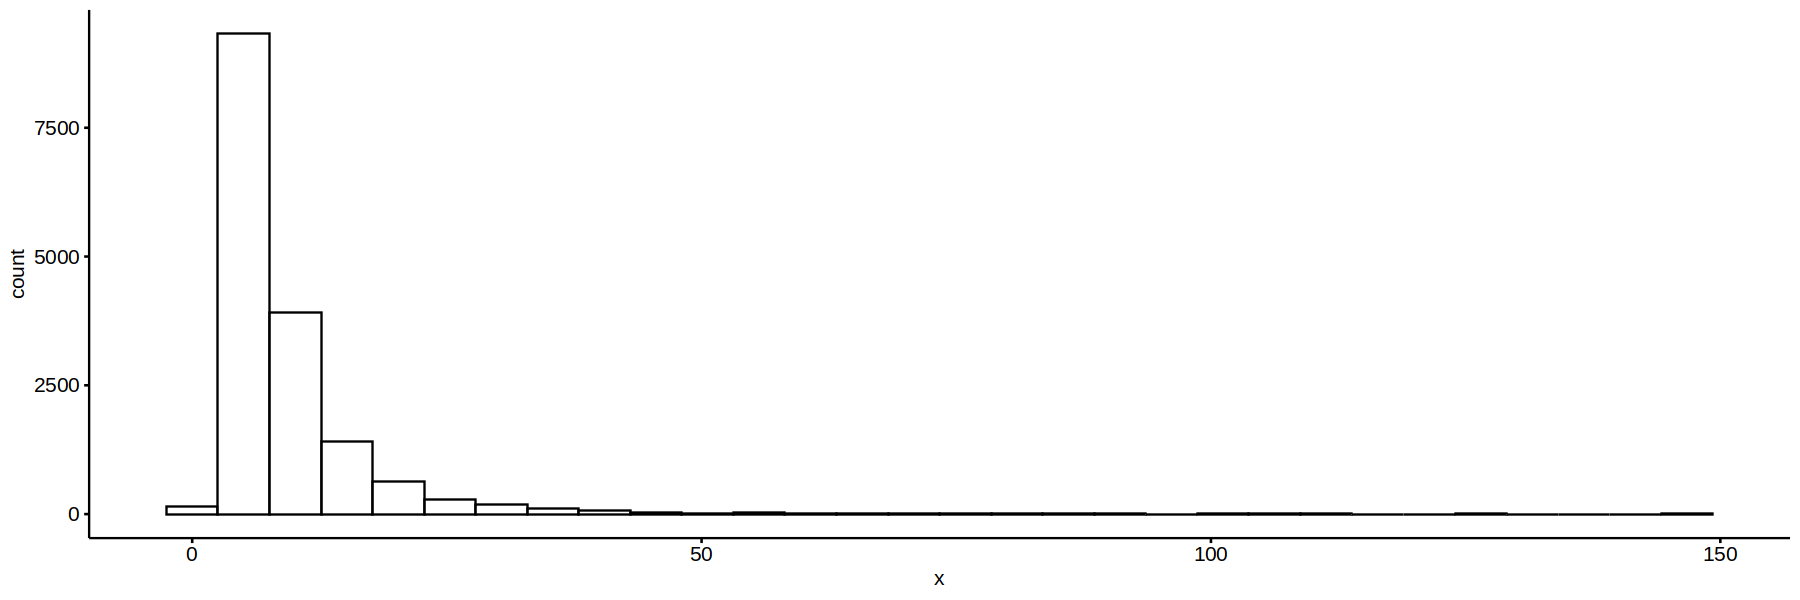

In [34]:
options(repr.plot.width=15, repr.plot.height=5)
gghistogram(zfp462[V5<150]$V5)

In [35]:
nrow(zfp462)

[1] 16264

In [36]:
library(BSgenome.Mmusculus.UCSC.mm10)

In [68]:
zfp462.gr = makeGRangesFromDataFrame(zfp462[order(-V5)][V5>0][,c(1,2,3)] %>% 
                                         setnames(c('chr', 'start', 'end')) %>% 
                                        .[chr %in% paste0('chr', c(1:19, 'X'))] %>% head(10000))
zfp462.gr = GRangesList(zfp462.gr)
names(zfp462.gr) = 'Zfp462'

seFoot_zfp <- getFootprints(
  ArchRProj = ArchRProject, 
  positions = zfp462.gr, 
  groupBy = "celltypeV1_genotype",
  flank = 2000 
)

keep = unique(meta2$celltypes_v1)
mclapply(keep, function(x){
    plotFootprints(
      seFoot = seFoot_zfp[, c(grep(paste0(x, '_Eomes_KO'), colnames(seFoot_zfp)),
                         grep(paste0(x, '_WT'), colnames(seFoot_zfp)))],
      ArchRProj = ArchRProject, 
      normMethod = "subtract",
      plotName = paste0('Footprints_Zfp462_top3000_2kbFlank_', x),
      addDOC = FALSE,
      smoothWindow = 100
)
}, mc.cores=12)

ArchR logging to : ArchRLogs/ArchR-getFootprints-110849dcebfbe-Date-2023-05-30_Time-01-12-02.log
If there is an issue, please report to github with logFile!

2023-05-30 01:12:03 : Computing Kmer Bias Table, 0.003 mins elapsed.

2023-05-30 01:12:05 : Finished Computing Kmer Tables, 0.042 mins elapsed.

2023-05-30 01:12:05 : Computing Footprints, 0.044 mins elapsed.

2023-05-30 01:12:14 : Computing Footprints Bias, 0.187 mins elapsed.

2023-05-30 01:12:16 : Summarizing Footprints, 0.221 mins elapsed.



[[1]]
[1] 0

[[2]]
[1] 0

[[3]]
[1] 0

[[4]]
[1] 0

[[5]]
[1] 0